<a href="https://colab.research.google.com/github/ishita332/Pixels-to-Parcels/blob/main/Assignment2_ishitaagrawal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip from Drive into Colab
import zipfile, os

# Change this filename to match yours exactly
zip_path = '/content/drive/MyDrive/spacenet.zip'   # ← change if name is different

print(f"Unzipping {zip_path} ...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/spacenet_raw')

print("✅ Done!")

# See folder structure
for root, dirs, files in os.walk('/content/spacenet_raw'):
    level = root.replace('/content/spacenet_raw', '').count(os.sep)
    if level < 4:
        print('  ' * level + os.path.basename(root) + f'/  ({len(files)} files)')

Mounted at /content/drive
Unzipping /content/drive/MyDrive/spacenet.zip ...
✅ Done!
spacenet_raw/  (0 files)
  AOI_3_Paris_Train/  (0 files)
    AOI_3_Paris_Train/  (0 files)
      geojson/  (0 files)
      RGB-PanSharpen/  (951 files)
      summaryData/  (1 files)
  AOI_3_Paris_Test_public/  (0 files)
    AOI_3_Paris_Test_public/  (0 files)
      RGB-PanSharpen/  (381 files)


In [5]:
!pip install rasterio

import os, glob, shutil, json, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import shape
from sklearn.model_selection import train_test_split
import rasterio # Import rasterio for georeferencing

print("✅ All imports done")

TRAIN_IMGS = '/content/spacenet_raw/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen'
TRAIN_JSON = '/content/spacenet_raw/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson'
TEST_IMGS  = '/content/spacenet_raw/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen'
BASE       = '/content/yolo_dataset'

print("Train images folder :", TRAIN_IMGS)
print("Train labels folder :", TRAIN_JSON)
print("Test images folder  :", TEST_IMGS)

# Quick check folders exist
for p in [TRAIN_IMGS, TRAIN_JSON, TEST_IMGS]:
    exists = "✅" if os.path.exists(p) else "❌ NOT FOUND"
    print(f"{exists}  {p}")

# Corrected indentation for directory creation
for split in ['train', 'val', 'test']:
    os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

print("✅ YOLO folder structure created:")
for split in ['train', 'val', 'test']:
    print(f"  {BASE}/images/{split}/")
    print(f"  {BASE}/labels/{split}/")


def geojson_to_yolo(geojson_path, transform, img_w, img_h):
    """
    Converts a SpaceNet GeoJSON label file into YOLO format.
    Requires rasterio transform and image pixel dimensions for coordinate conversion.
    Returns a list of strings like: '0 cx cy w h'
    """
    lines = []
    debug_poly_counter = 0 # To limit debug prints
    try:
        with open(geojson_path) as f:
            data = json.load(f)
        for feature in data.get('features', []):
            geom = feature.get('geometry')
            if geom is None:
                continue
            if geom['type'] == 'Point':
                # Skip point geometries
                continue
            try:
                poly = shape(geom)
                min_lon, min_lat, max_lon, max_lat = poly.bounds

                # Convert geographic coordinates (lon, lat) to pixel coordinates (col, row)
                # using the image's georeferencing transform.
                # Note: rasterio transform maps (col, row) to (x_geo, y_geo).
                # Inverse transform ~transform maps (x_geo, y_geo) to (col, row).
                # max_lat corresponds to top row (min_y_pixel), min_lat corresponds to bottom row (max_y_pixel)
                top_left_col, top_left_row = ~transform * (min_lon, max_lat)
                bottom_right_col, bottom_right_row = ~transform * (max_lon, min_lat)

                # Determine actual pixel bounding box (x1, y1, x2, y2)
                x1_pix = int(round(min(top_left_col, bottom_right_col)))
                y1_pix = int(round(min(top_left_row, bottom_right_row)))
                x2_pix = int(round(max(top_left_col, bottom_right_col)))
                y2_pix = int(round(max(top_left_row, bottom_right_row)))

                # Clip bounding box to image boundaries (0 to img_w-1, 0 to img_h-1)
                x1_pix = max(0, x1_pix)
                y1_pix = max(0, y1_pix)
                x2_pix = min(img_w - 1, x2_pix)
                y2_pix = min(img_h - 1, y2_pix)

                # Calculate center, width, height in pixel coordinates
                center_x_pix = (x1_pix + x2_pix) / 2.0
                center_y_pix = (y1_pix + y2_pix) / 2.0
                width_pix    = x2_pix - x1_pix
                height_pix   = y2_pix - y1_pix

                # Skip degenerate bounding boxes after conversion to pixels
                if width_pix <= 0 or height_pix <= 0:
                    if debug_poly_counter < 5:
                        print(f"  DEBUG Degenerate Pixel Box SKIPPED for {Path(geojson_path).name}: pixel_width={width_pix:.2f}, pixel_height={height_pix:.2f}")
                        debug_poly_counter += 1
                    continue

                # Normalize to YOLO format (cx, cy, w, h)
                cx = center_x_pix / img_w
                cy = center_y_pix / img_h
                w  = width_pix / img_w
                h  = height_pix / img_h

                if debug_poly_counter < 5:
                    print(f"  DEBUG GeoJSON Bounds: lon={min_lon:.4f},{max_lon:.4f} lat={min_lat:.4f},{max_lat:.4f}")
                    print(f"  DEBUG Pixel Bounds for {Path(geojson_path).name}: x1={x1_pix:.2f}, y1={y1_pix:.2f}, x2={x2_pix:.2f}, y2={y2_pix:.2f}")
                    print(f"  DEBUG Normalized YOLO for {Path(geojson_path).name}: cx={cx:.6f}, cy={cy:.6f}, w={w:.6f}, h={h:.6f}")
                    debug_poly_counter += 1

                # Original filtering condition (adjusted if needed, but should work with correct pixel coords)
                if 0 < cx < 1 and 0 < cy < 1 and w > 0.001 and h > 0.001:
                    lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                else:
                    if debug_poly_counter < 5:
                        print(f"  DEBUG YOLO bbox SKIPPED by threshold (out of bounds or too small) for {Path(geojson_path).name}: cx={cx:.4f}, cy={cy:.4f}, w={w:.6f}, h={h:.6f}")

            except Exception as inner_e:
                print(f"  Inner Warning: Could not process geometry in {geojson_path}: {inner_e}")
                continue
    except Exception as e:
        print(f"  Warning: could not read {geojson_path}: {e}")
    return lines

print("✅ Conversion function defined")
sample_imgs = (glob.glob(f'{TRAIN_IMGS}/*.tif') +
               glob.glob(f'{TRAIN_IMGS}/*.png') +
               glob.glob(f'{TRAIN_IMGS}/*.jpg'))

print(f"Total training images found: {len(sample_imgs)}")

# Image dimensions will be read by rasterio later in process_and_copy,
# but keeping default for initial checks if needed.
IMG_W, IMG_H = 650, 650

# This block is now less critical as rasterio will determine image dimensions per image
# but good for a general idea.
if sample_imgs:
    try:
        with rasterio.open(sample_imgs[0]) as src:
            IMG_H, IMG_W = src.height, src.width
            print(f"✅ Detected image size using rasterio: {IMG_W} x {IMG_H}")
    except Exception as e:
        print(f"⚠️  Could not read first image with rasterio ({e}). Using default size: {IMG_W} x {IMG_H}")

geojson_files = (glob.glob(f'{TRAIN_JSON}/**/*.geojson', recursive=True) +
                 glob.glob(f'{TRAIN_JSON}/*.geojson'))

print(f"GeoJSON files found: {len(geojson_files)}")

# Initialize geojson_dict
geojson_dict = {}

for g in geojson_files:
    stem = Path(g).stem
    key  = stem.replace('buildings_AOI_3_Paris_', '')
    geojson_dict[key] = g

print(f"GeoJSON dict entries: {len(geojson_dict)}")
print("Sample keys:", list(geojson_dict.keys())[:5])
paired    = []
unmatched = []

for img_path in sample_imgs:
    stem = Path(img_path).stem
    key_variants = [
        stem,
        stem.replace('RGB-PanSharpen_AOI_3_Paris_', ''),
        stem.replace('RGB_', ''),
        stem.replace('Pan_', ''),
    ]
    matched = None
    for key in key_variants:
        if key in geojson_dict:
            matched = geojson_dict[key]
            break
    if matched:
        paired.append((img_path, matched))
    else:
        unmatched.append(img_path)

print(f"✅ Matched image-label pairs : {len(paired)}")
print(f"⚠️  Unmatched (no label)     : {len(unmatched)}")
if unmatched:
    print(f"   Example unmatched: {Path(unmatched[0]).stem}")



train_pairs, temp      = train_test_split(paired, test_size=0.2, random_state=42)
val_pairs,   test_pairs = train_test_split(temp,  test_size=0.5, random_state=42)

print(f"✅ Split complete:")
print(f"   Train : {len(train_pairs)} images")
print(f"   Val   : {len(val_pairs)}   images")
print(f"   Test  : {len(test_pairs)}  images")


def process_and_copy(pairs, split):
    count = 0
    for img_src, geojson_src in pairs:
        img_name = Path(img_src).stem + '.png'
        lbl_name = Path(img_src).stem + '.txt'
        img_dst  = f'{BASE}/images/{split}/{img_name}'
        lbl_dst  = f'{BASE}/labels/{split}/{lbl_name}'

        try:
            # Use rasterio to open image and get georeferencing info and dimensions
            with rasterio.open(img_src) as src:
                raster_img_w = src.width
                raster_img_h = src.height
                img_transform = src.transform

            # Use cv2 to read and process image data (converting to 8-bit if needed)
            img = cv2.imread(img_src, cv2.IMREAD_UNCHANGED)
            if img is not None:
                if img.dtype != np.uint8:
                    # Normalize high bit-depth images to 8-bit for YOLO/display
                    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Remove alpha channel if present
                if len(img.shape) == 3 and img.shape[2] == 4:
                    img = img[:, :, :3]

                # Save image to destination
                cv2.imwrite(img_dst, img)
            else:
                # Fallback: if cv2 can't read, just copy raw image (may cause issues later if not 8-bit)
                print(f"  Warning: cv2.imread failed for {img_src}. Copying raw file.")
                shutil.copy2(img_src, img_dst)

            # Generate YOLO labels using rasterio's transform and dimensions
            yolo_lines = geojson_to_yolo(geojson_src, img_transform, raster_img_w, raster_img_h)
            with open(lbl_dst, 'w') as f:
                f.write('\n'.join(yolo_lines))
            count += 1
        except rasterio.errors.RasterioIOError as e:
            print(f"  Warning: Could not open {img_src} with rasterio: {e}. Skipping image and labels.")
            continue
        except Exception as e:
            print(f"  Error processing {img_src}: {e}. Skipping image and labels.")
            continue

    print(f"✅ {split:5s} : {count} images copied, labels generated")

process_and_copy(train_pairs, 'train')
process_and_copy(val_pairs,   'val')
process_and_copy(test_pairs,  'test')


print("📂 Final YOLO dataset:")
for split in ['train', 'val', 'test']:
    n_imgs = len(os.listdir(f'{BASE}/images/{split}'))
    n_lbls = len(os.listdir(f'{BASE}/labels/{split}'))
    print(f"  {split:5s} → {n_imgs} images  |  {n_lbls} labels")

Streaming output truncated to the last 5000 lines.
  DEBUG Normalized YOLO for buildings_AOI_3_Paris_img1368.geojson: cx=0.706154, cy=0.866923, w=0.095385, h=0.078462
  DEBUG GeoJSON Bounds: lon=2.2791,2.2793 lat=49.0058,49.0059
  DEBUG Pixel Bounds for buildings_AOI_3_Paris_img1368.geojson: x1=539.00, y1=524.00, x2=603.00, y2=565.00
  DEBUG Normalized YOLO for buildings_AOI_3_Paris_img1368.geojson: cx=0.878462, cy=0.837692, w=0.098462, h=0.063077
  DEBUG GeoJSON Bounds: lon=2.2790,2.2791 lat=49.0063,49.0063
  DEBUG Pixel Bounds for buildings_AOI_3_Paris_img1368.geojson: x1=489.00, y1=375.00, x2=517.00, y2=391.00
  DEBUG Normalized YOLO for buildings_AOI_3_Paris_img1368.geojson: cx=0.773846, cy=0.589231, w=0.043077, h=0.024615
  DEBUG GeoJSON Bounds: lon=2.2792,2.2794 lat=49.0062,49.0064
  DEBUG Pixel Bounds for buildings_AOI_3_Paris_img1368.geojson: x1=579.00, y1=365.00, x2=649.00, y2=415.00
  DEBUG Normalized YOLO for buildings_AOI_3_Paris_img1368.geojson: cx=0.944615, cy=0.600000, w

📊 Image counts per split:
  train : 759 images
  val   : 95 images
  test  : 95 images


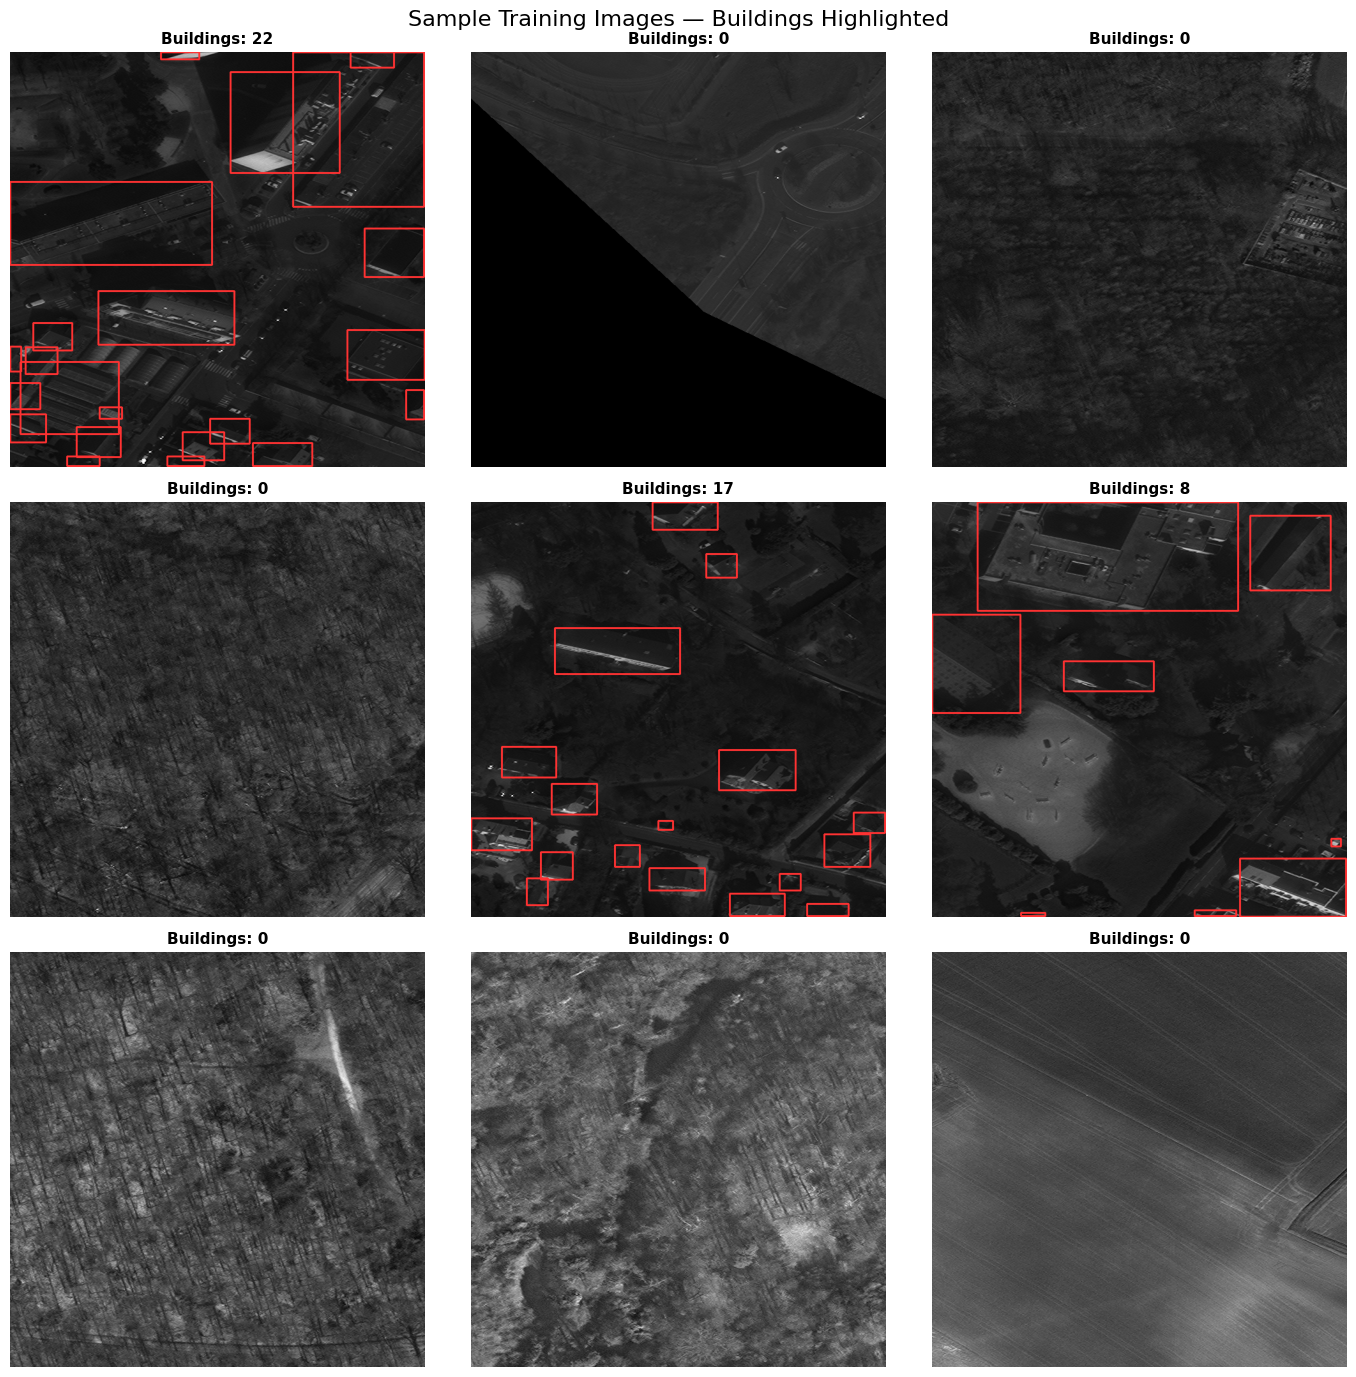

 Grid saved → /content/sample_grid.png
 Training Set Statistics:
  Average buildings per image : 13.61
  Median                      : 1
  Max buildings in one image  : 81
  Min buildings               : 0
  Images with 0 buildings     : 352


In [6]:
print("📊 Image counts per split:")
for split in ['train', 'val', 'test']:
    n = len(os.listdir(f'{BASE}/images/{split}'))
    print(f"  {split:5s} : {n} images")

train_imgs = glob.glob(f'{BASE}/images/train/*.png')
sample_9   = random.sample(train_imgs, min(9, len(train_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("Sample Training Images — Buildings Highlighted", fontsize=16)

for ax, img_path in zip(axes.flatten(), sample_9):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path    = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    n_buildings = 0

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        n_buildings = len(lines)
        for line in lines:
            parts = line.split()
            if len(parts) == 5:
                _, cx, cy, bw, bh = map(float, parts)
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255, 50, 50), 2)

    ax.imshow(img)
    ax.set_title(f"Buildings: {n_buildings}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grid saved → /content/sample_grid.png")

all_label_files = glob.glob(f'{BASE}/labels/train/*.txt')
counts = []
for lbl in all_label_files:
    with open(lbl) as f:
        lines = [l for l in f if l.strip()]
    counts.append(len(lines))

print(" Training Set Statistics:")
print(f"  Average buildings per image : {np.mean(counts):.2f}")
print(f"  Median                      : {np.median(counts):.0f}")
print(f"  Max buildings in one image  : {max(counts)}")
print(f"  Min buildings               : {min(counts)}")
print(f"  Images with 0 buildings     : {counts.count(0)}")

📊 Image counts per split:
  train : 759 images
  val   : 95 images
  test  : 95 images


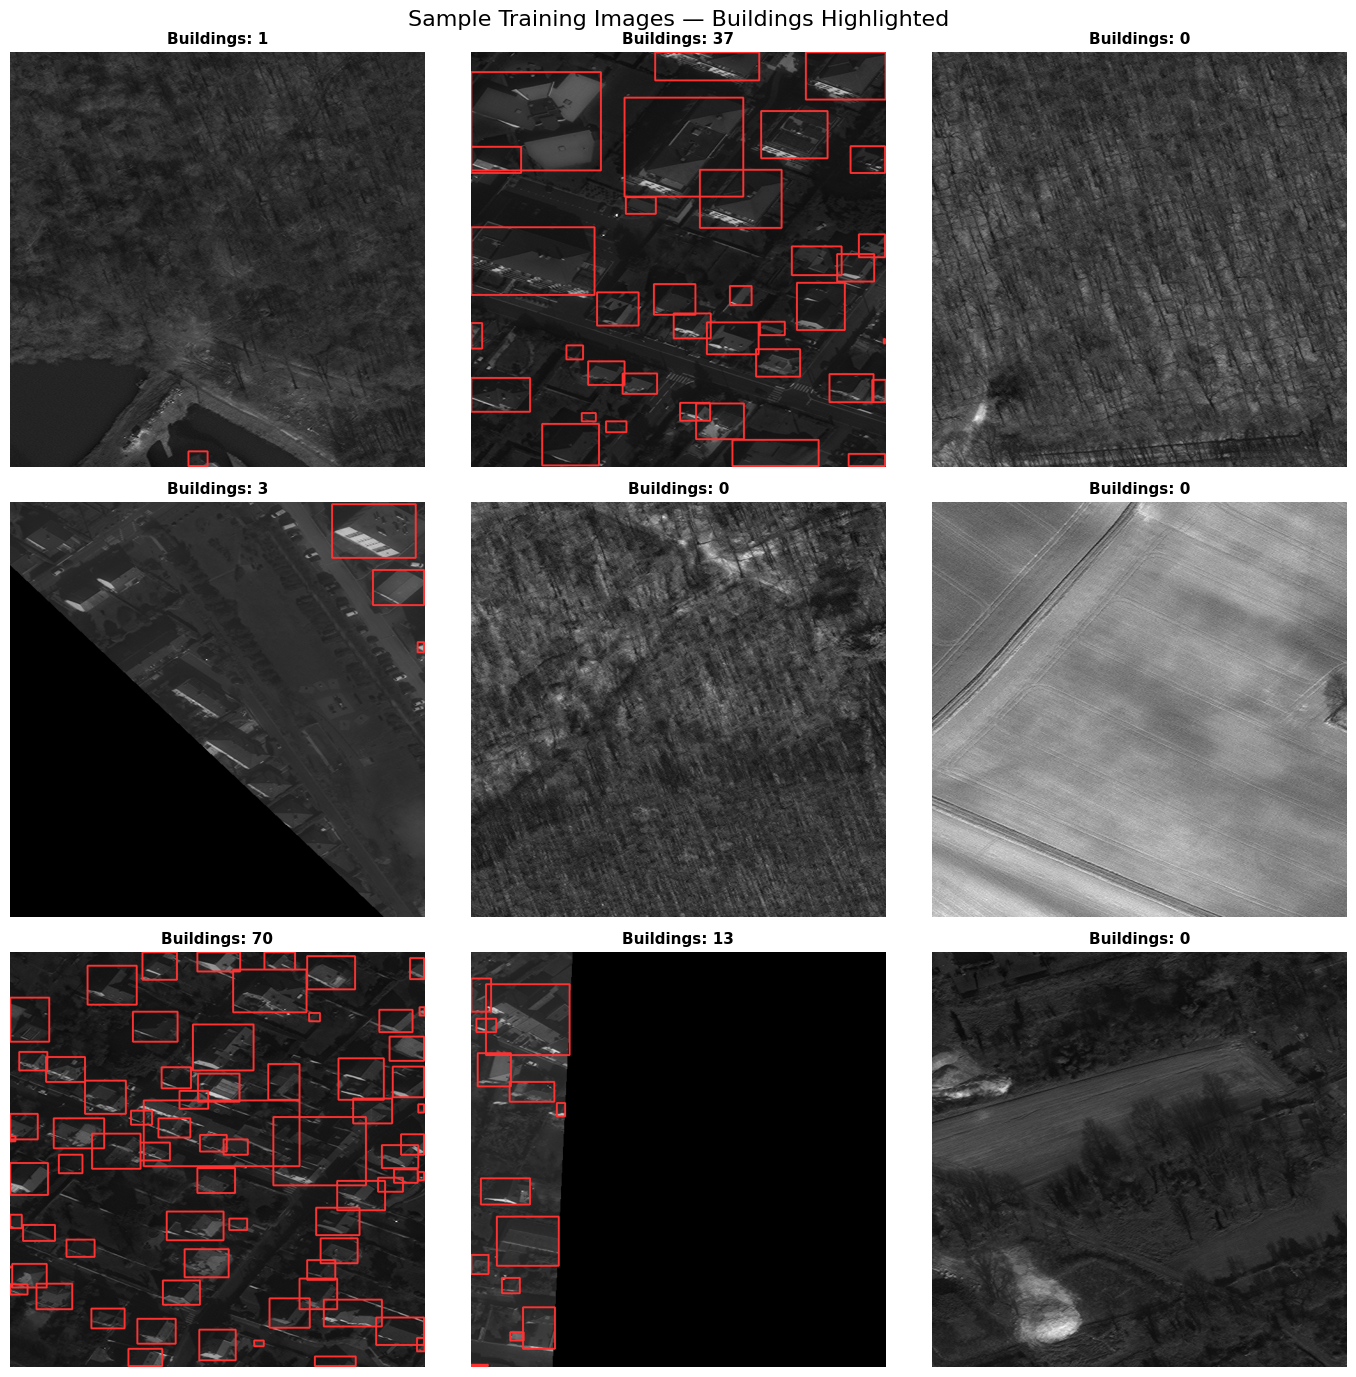

 Grid saved → /content/sample_grid.png
 Training Set Statistics:
  Average buildings per image : 13.61
  Median                      : 1
  Max buildings in one image  : 81
  Min buildings               : 0
  Images with 0 buildings     : 352


In [7]:
print("📊 Image counts per split:")
for split in ['train', 'val', 'test']:
    n = len(os.listdir(f'{BASE}/images/{split}'))
    print(f"  {split:5s} : {n} images")

train_imgs = glob.glob(f'{BASE}/images/train/*.png')
sample_9   = random.sample(train_imgs, min(9, len(train_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("Sample Training Images — Buildings Highlighted", fontsize=16)

for ax, img_path in zip(axes.flatten(), sample_9):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path    = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    n_buildings = 0

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        n_buildings = len(lines)
        for line in lines:
            parts = line.split()
            if len(parts) == 5:
                _, cx, cy, bw, bh = map(float, parts)
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255, 50, 50), 2)

    ax.imshow(img)
    ax.set_title(f"Buildings: {n_buildings}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grid saved → /content/sample_grid.png")

all_label_files = glob.glob(f'{BASE}/labels/train/*.txt')
counts = []
for lbl in all_label_files:
    with open(lbl) as f:
        lines = [l for l in f if l.strip()]
    counts.append(len(lines))

print(" Training Set Statistics:")
print(f"  Average buildings per image : {np.mean(counts):.2f}")
print(f"  Median                      : {np.median(counts):.0f}")
print(f"  Max buildings in one image  : {max(counts)}")
print(f"  Min buildings               : {min(counts)}")
print(f"  Images with 0 buildings     : {counts.count(0)}")

In [8]:
yaml_content = f"""path: {BASE}
train: images/train
val:   images/val
test:  images/test

nc: 1
names: ['building']
"""

with open('/content/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ dataset.yaml created:")
print(yaml_content)



✅ dataset.yaml created:
path: /content/yolo_dataset
train: images/train
val:   images/val
test:  images/test

nc: 1
names: ['building']



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8s model loaded (pretrained on COCO)
   Parameters: 11166560
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False,

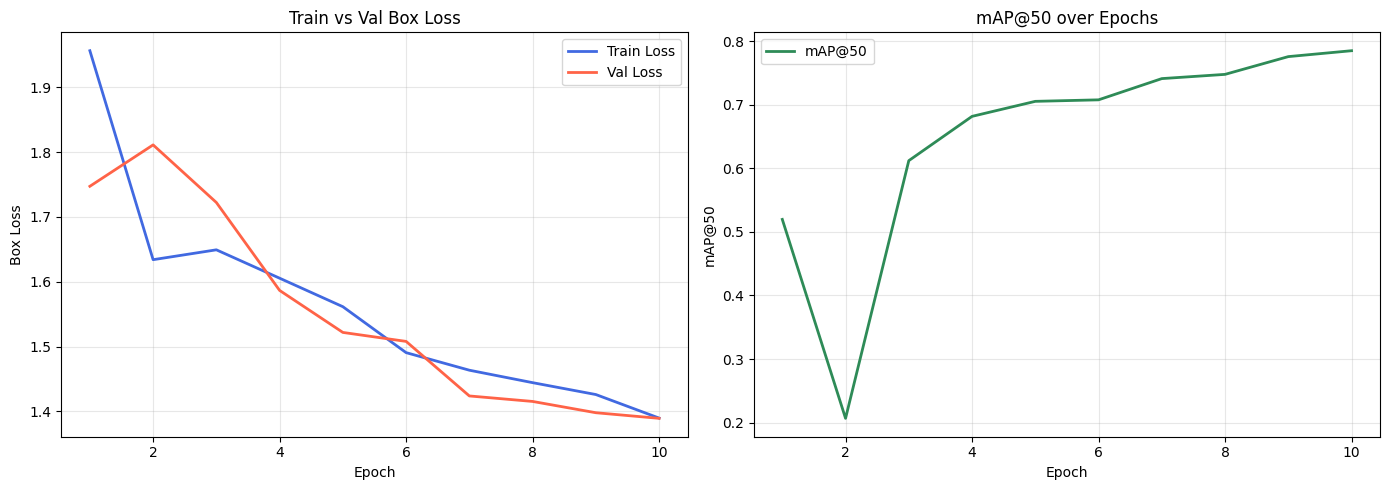

✅ Saved → /content/training_curves.png


In [10]:
# Install Ultralytics (YOLOv8)
!pip install ultralytics -q


from ultralytics import YOLO

model = YOLO('yolov8s.pt')
print("✅ YOLOv8s model loaded (pretrained on COCO)")
print("   Parameters:", sum(p.numel() for p in model.model.parameters()))
results = model.train(
    data     = '/content/dataset.yaml',
    epochs   = 10,
    imgsz    = 640,
    batch    = 16,
    name     = 'building_detector',
    project  = 'runs/detect',
    patience = 10,
    device   = 0,
    workers  = 2,
    exist_ok = True,
)
print("✅ Training complete!")

import pandas as pd

csv_path = 'runs/detect/runs/detect/building_detector/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

print("Column names:", df.columns.tolist())

last = df.iloc[-1]
print(f"\n📊 Final Epoch Results:")
print(f"  Train box_loss : {last['train/box_loss']:.4f}")
print(f"  Val box_loss   : {last['val/box_loss']:.4f}")
print(f"  mAP@50         : {last['metrics/mAP50(B)']:.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df['epoch'], df['train/box_loss'], label='Train Loss', color='royalblue', linewidth=2)
ax1.plot(df['epoch'], df['val/box_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Box Loss')
ax1.set_title('Train vs Val Box Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df['epoch'], df['metrics/mAP50(B)'], color='seagreen', linewidth=2, label='mAP@50')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mAP@50')
ax2.set_title('mAP@50 over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print("✅ Saved → /content/training_curves.png")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2107.4±473.6 MB/s, size: 226.0 KB)
val: Scanning /content/yolo_dataset/labels/test... 95 images, 39 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 1.3Kit/s 0.1s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.0it/s 5.9s
                   all         95       1413      0.787      0.706      0.782      0.466
Speed: 14.5ms preprocess, 10.5ms inference, 0.0ms loss, 7.5ms postprocess per image
Results saved to /content/runs/detect/val

Metric       Value     Plain English
─────────────────────────────────────────────────────────────────
mAP@50       0.7816   Avg accuracy at 50% overlap threshold
Precision    0.7866   Of all predicted boxes, how many 

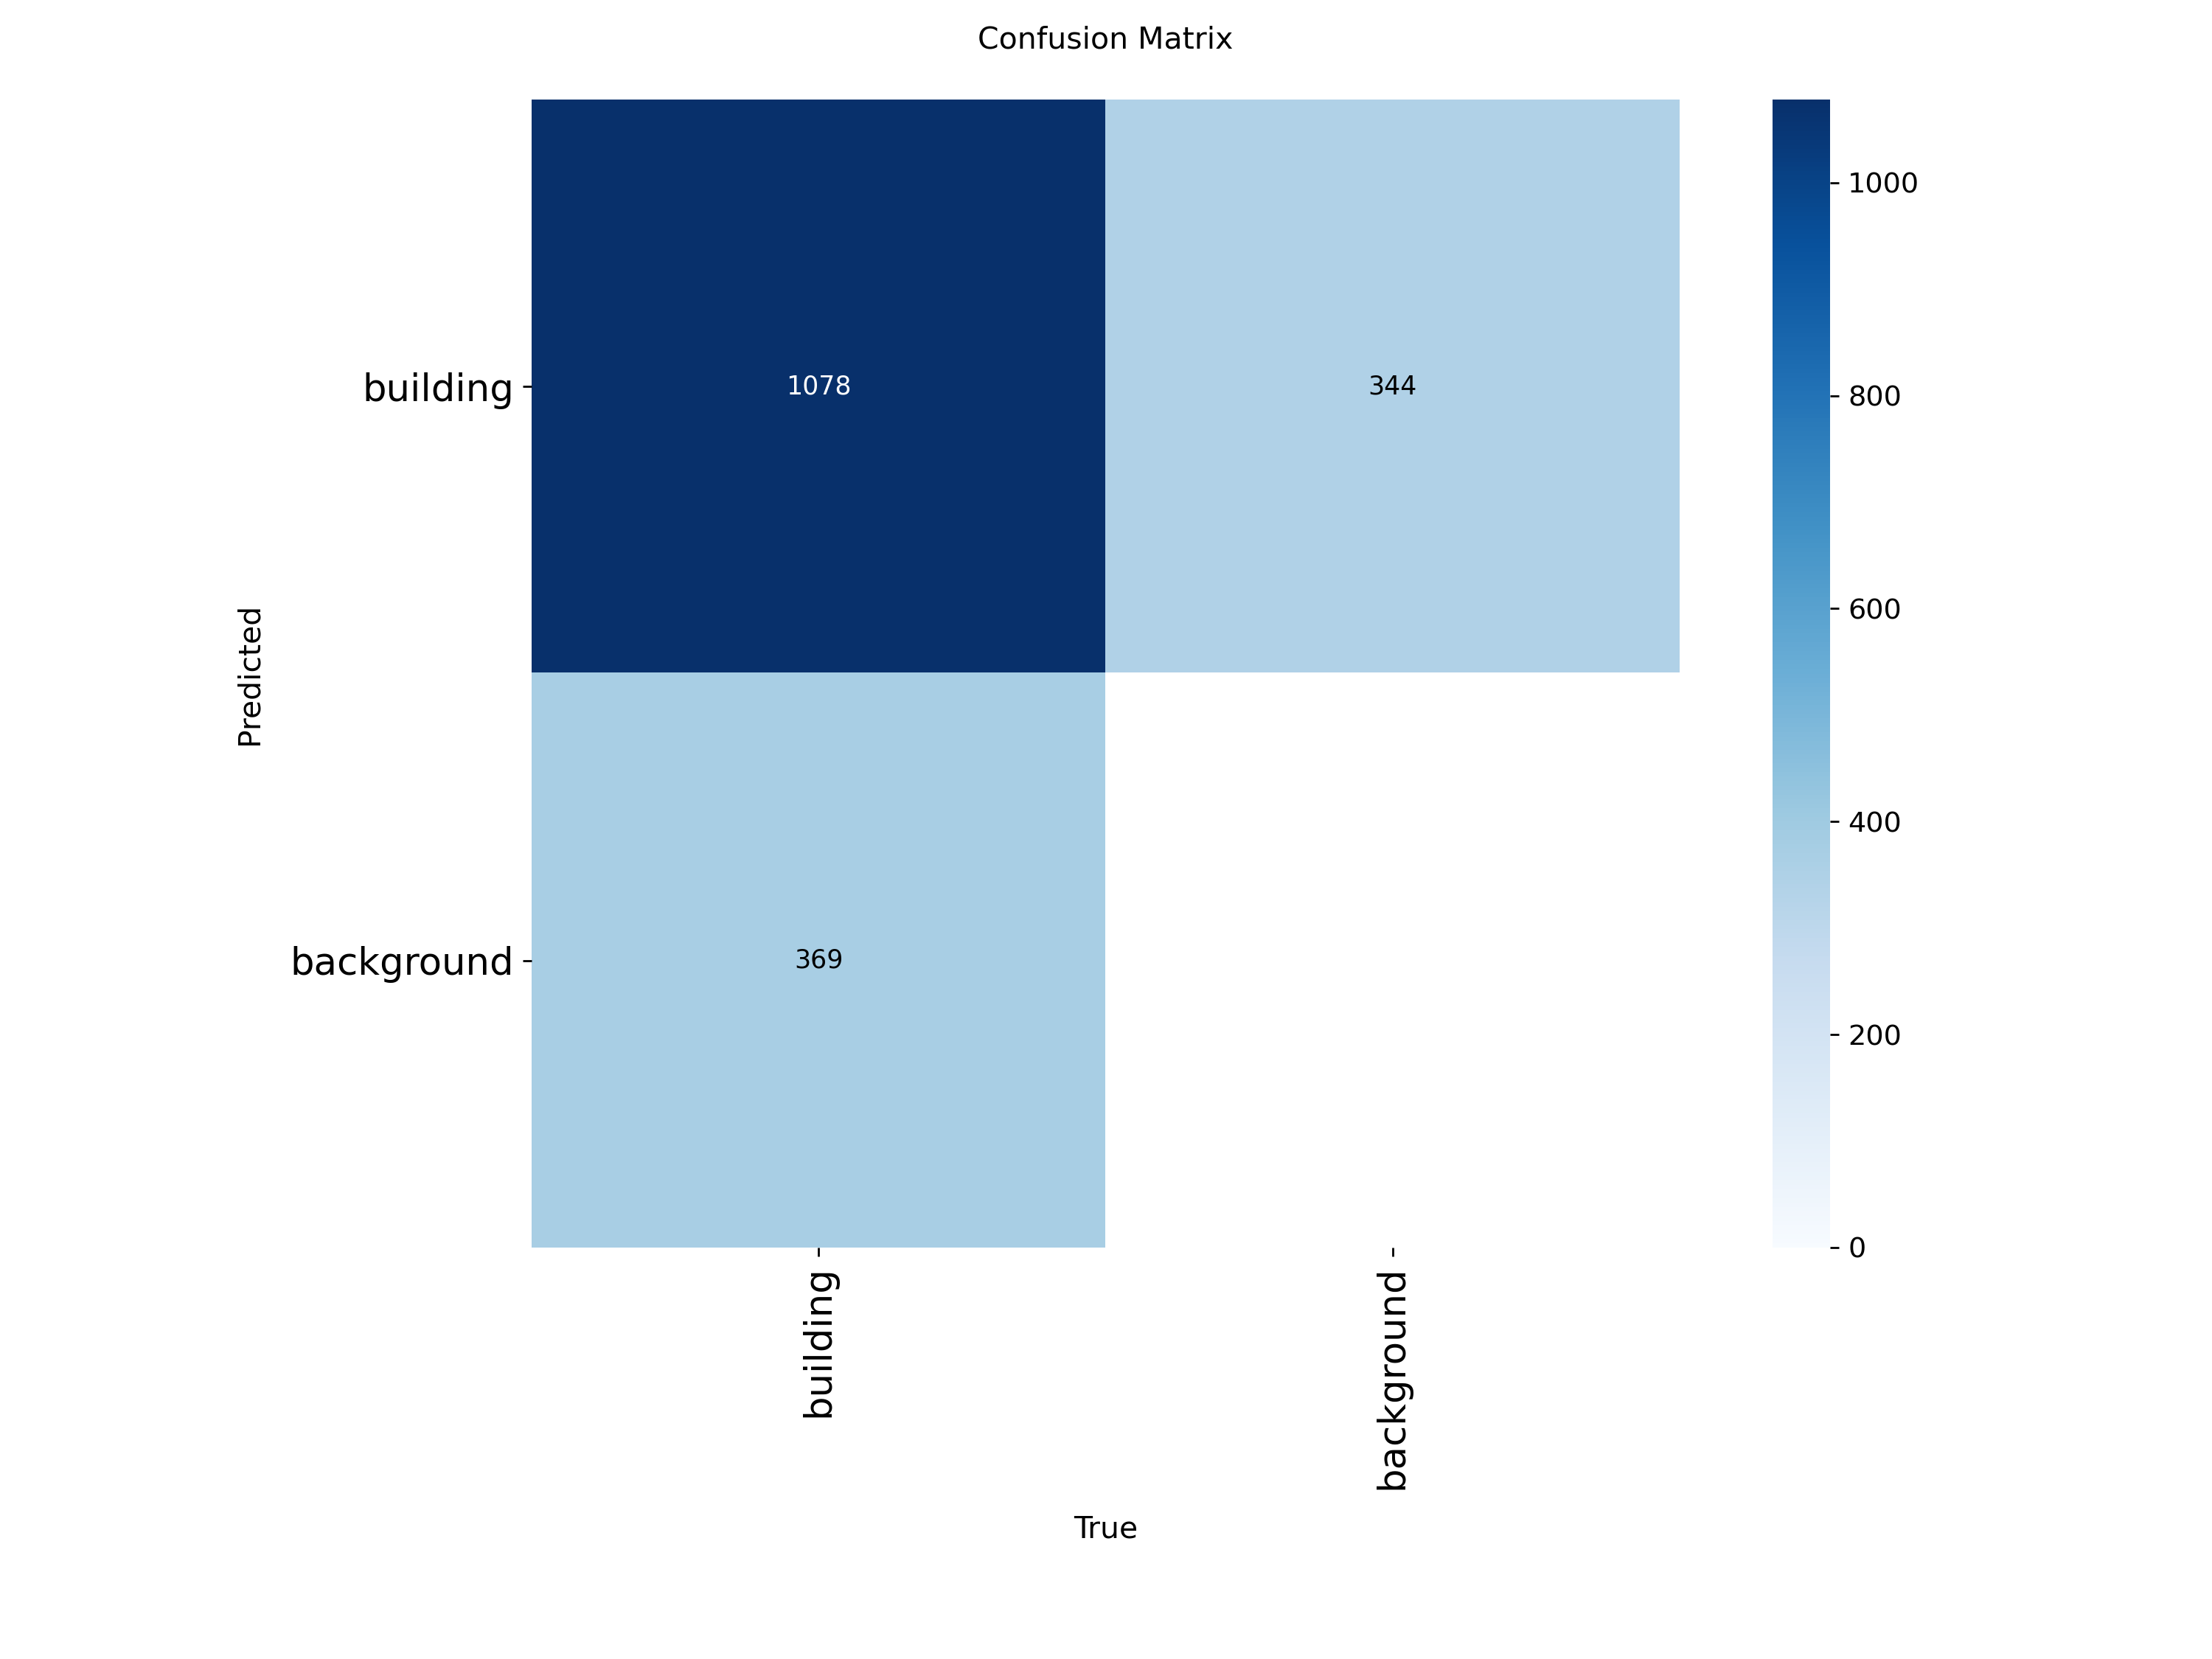

In [11]:
model = YOLO('/content/runs/detect/runs/detect/building_detector/weights/best.pt')

metrics = model.val(
    data   = '/content/dataset.yaml',
    split  = 'test',
    imgsz  = 640,
    device = 0,
)

precision = metrics.box.mp
recall    = metrics.box.mr
map50     = metrics.box.map50
f1        = 2 * precision * recall / (precision + recall + 1e-9)

print(f"\n{'Metric':<12} {'Value':<8}  Plain English")
print("─" * 65)
print(f"{'mAP@50':<12} {map50:.4f}   Avg accuracy at 50% overlap threshold")
print(f"{'Precision':<12} {precision:.4f}   Of all predicted boxes, how many were real")
print(f"{'Recall':<12} {recall:.4f}   Of all real buildings, how many were found")
print(f"{'F1 Score':<12} {f1:.4f}   Balance between precision and recall")



from IPython.display import Image as IPImage, display

pr_path = '/content/runs/detect/runs/detect/building_detector/PR_curve.png'
if os.path.exists(pr_path):
    print("Precision-Recall Curve:")
    display(IPImage(pr_path, width=600))
else:
    print("PR curve not found at:", pr_path)


cm_path = '/content/runs/detect/runs/detect/building_detector/confusion_matrix.png'
if os.path.exists(cm_path):
    print("Confusion Matrix:")
    display(IPImage(cm_path, width=600))
else:
    print("Confusion matrix not found at:", cm_path)

✅ detect_buildings() function ready
  _3_Paris_img1851.png    True:   0  Pred:   0
  _3_Paris_img1735.png    True:   4  Pred:   3
  _3_Paris_img1858.png    True:   0  Pred:   1
  _3_Paris_img1566.png    True:   0  Pred:   0
  I_3_Paris_img735.png    True:  68  Pred:  70
  I_3_Paris_img480.png    True:  47  Pred:  43
  I_3_Paris_img638.png    True:  16  Pred:  16
  I_3_Paris_img188.png    True:  29  Pred:  17
  _3_Paris_img1446.png    True:  42  Pred:  35
  _3_Paris_img1706.png    True:   0  Pred:   0

✅ Mean Absolute Error: 2.70 buildings


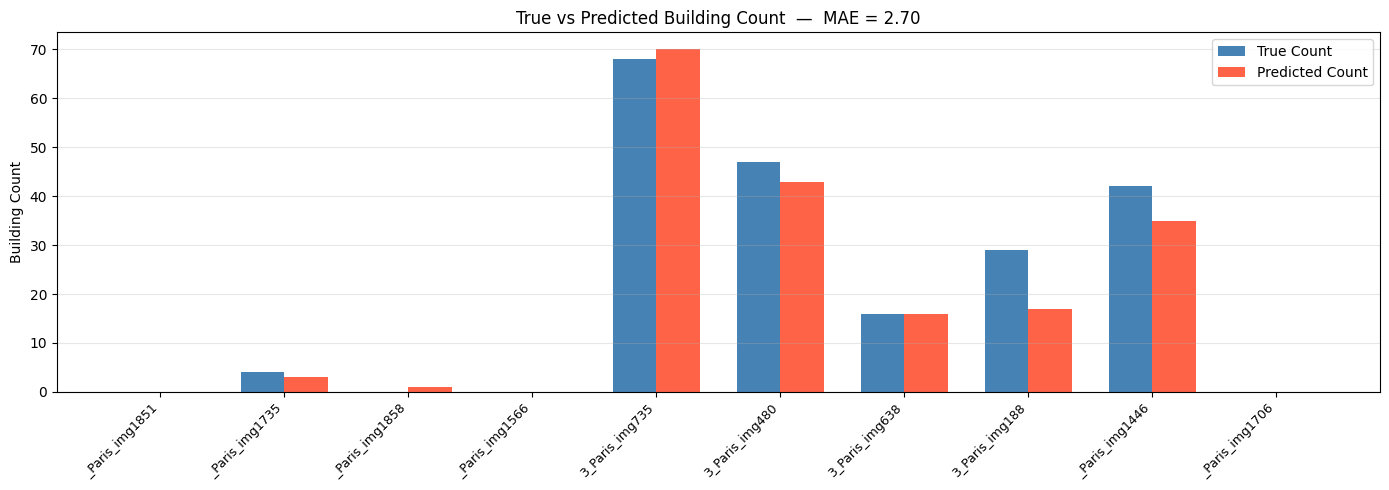

✅ Saved → /content/count_comparison.png
✅ full_pipeline() function ready


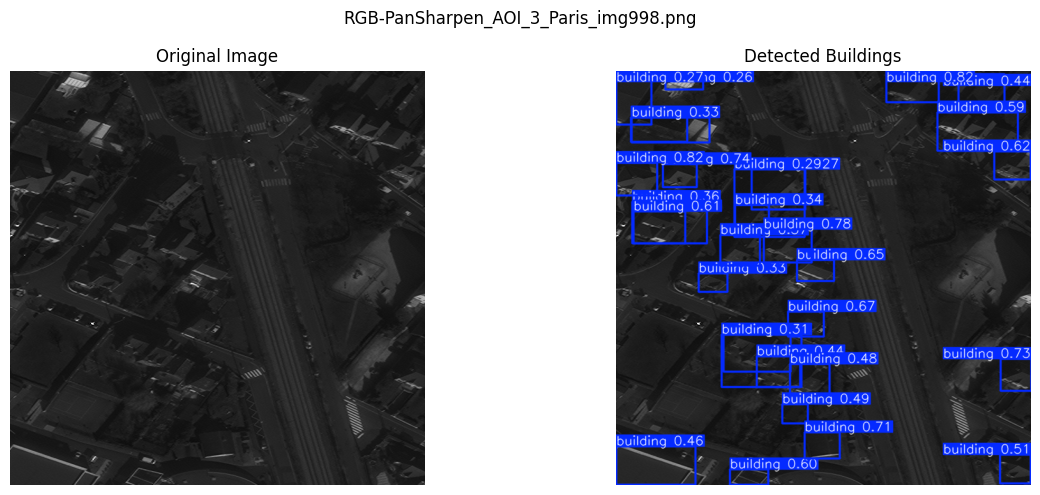

Image              : RGB-PanSharpen_AOI_3_Paris_img998.png
Buildings detected : 30
Avg confidence     : 0.49
Processing time    : 70.6 ms
────────────────────────────────────────


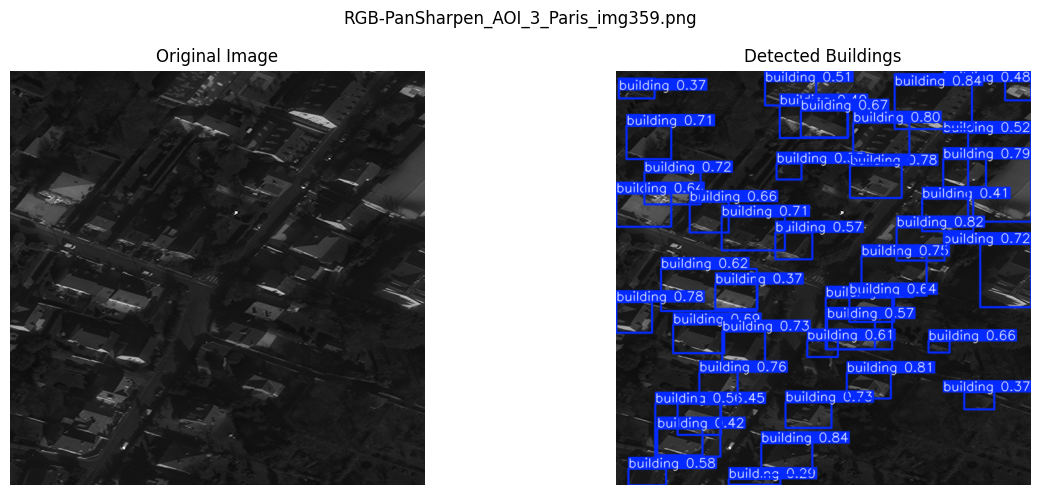

Image              : RGB-PanSharpen_AOI_3_Paris_img359.png
Buildings detected : 41
Avg confidence     : 0.61
Processing time    : 119.4 ms
────────────────────────────────────────


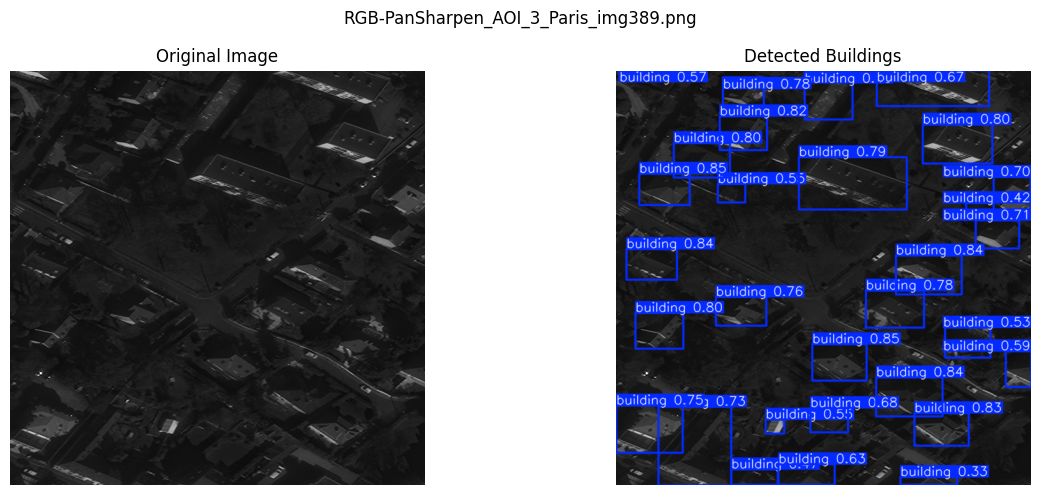

Image              : RGB-PanSharpen_AOI_3_Paris_img389.png
Buildings detected : 30
Avg confidence     : 0.69
Processing time    : 109.0 ms
────────────────────────────────────────


In [12]:
import time

model = YOLO('/content/runs/detect/runs/detect/building_detector/weights/best.pt')

def detect_buildings(image_path, conf=0.25):
    """
    Detects buildings in a satellite image.
    Returns: dict with count, avg_confidence, processing_time_ms, annotated_image
    """
    start   = time.time()
    results = model.predict(image_path, conf=conf, verbose=False)
    elapsed = (time.time() - start) * 1000

    result   = results[0]
    count    = len(result.boxes)
    avg_conf = float(result.boxes.conf.mean()) if count > 0 else 0.0
    annotated = result.plot()

    return {
        'image_path'        : image_path,
        'count'             : count,
        'avg_confidence'    : avg_conf,
        'processing_time_ms': elapsed,
        'annotated_image'   : annotated,
    }

print("✅ detect_buildings() function ready")



test_images = glob.glob(f'{BASE}/images/test/*.png')
sample_10   = random.sample(test_images, min(10, len(test_images)))

true_counts, pred_counts, names = [], [], []

for img_path in sample_10:
    lbl_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    true_n   = 0
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            true_n = len([l for l in f if l.strip()])

    out = detect_buildings(img_path)
    true_counts.append(true_n)
    pred_counts.append(out['count'])
    names.append(Path(img_path).stem[-14:])
    print(f"  {Path(img_path).name[-20:]:<22}  True: {true_n:3d}  Pred: {out['count']:3d}")

mae = np.mean(np.abs(np.array(true_counts) - np.array(pred_counts)))
print(f"\n✅ Mean Absolute Error: {mae:.2f} buildings")

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, true_counts, width, label='True Count',      color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted Count', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Building Count')
ax.set_title(f'True vs Predicted Building Count  —  MAE = {mae:.2f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/count_comparison.png', dpi=150)
plt.show()
print("✅ Saved → /content/count_comparison.png")

def full_pipeline(image_path, conf=0.25):
    """
    End-to-end pipeline:
    → loads image
    → runs detection
    → shows original vs annotated side by side
    → prints summary
    """
    out  = detect_buildings(image_path, conf=conf)
    orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    ann  = cv2.cvtColor(out['annotated_image'],  cv2.COLOR_BGR2RGB)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.imshow(orig); ax1.set_title('Original Image',     fontsize=12); ax1.axis('off')
    ax2.imshow(ann);  ax2.set_title('Detected Buildings', fontsize=12); ax2.axis('off')
    plt.suptitle(Path(image_path).name, fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Image              : {Path(image_path).name}")
    print(f"Buildings detected : {out['count']}")
    print(f"Avg confidence     : {out['avg_confidence']:.2f}")
    print(f"Processing time    : {out['processing_time_ms']:.1f} ms")
    print("─" * 40)

print("✅ full_pipeline() function ready")

sample_3 = random.sample(test_images, min(3, len(test_images)))

for img_path in sample_3:
    full_pipeline(img_path)